In [1]:
import re
import pathlib as pl
import tomllib
import colorsys
import matplotlib
import dataclasses
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from functools import cached_property, partial
from itertools import batched
from matplotlib.markers import MarkerStyle
from matplotlib.transforms import Affine2D
from tqdm.contrib.concurrent import process_map
from tqdm.notebook import tqdm

from common.project import UnzippedProject
from scatterplots import hr, load_tsv_file, load_txt, EpochInfo, plot_netsize_from_epochs
from swarmsim.yaml import safe_load

from seaborn.categorical import _CategoricalPlotter  # pyright: ignore[reportAttributeAccessIssue]
from seaborn.utils import _scatter_legend_artist, _default_color  # pyright: ignore[reportAttributeAccessIssue]

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.13.3)


In [2]:
matplotlib.rcParams['axes.titlesize'] = 14
matplotlib.rcParams['axes.labelsize'] = 12
# matplotlib.rcParams['legend.fontsize'] = 10
# matplotlib.rcParams['figure.dpi'] = 300
# matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['pgf.texsystem'] = 'xelatex'

sideways_dia = MarkerStyle('d', None, Affine2D().rotate_deg(90))

%matplotlib widget

In [3]:
class Run(UnzippedProject):
    @cached_property
    def fitness_df(self):
        data = load_tsv_file(self.popfit_path)
        df = pd.DataFrame(data).T
        df.index = ('time', 'epoch', 'fitnesses')
        df = df.T
        df['time'] = df['time'].astype(float)
        df['epoch'] = df['epoch'].astype(int)
        df['fitnesses'] = df['fitnesses'].apply(eval)
        return df

In [24]:
desktop = pl.Path('/mnt/c/Users/kenbl/Desktop').expanduser()

folder = desktop / 'four' / 'mill'
ns = (6, 20, 50)

folders = [folder / str(n) for n in ns]

projects = [Run(p)
            # for n in folder.iterdir() if n.is_dir() and 'zip' not in n.name
            for d in folders
            for p in d.iterdir() if 'TS1' in p.name]

In [5]:
projects[0].popfit_path
projects[0].experiment['args']['rngstrat']

'TS1'

In [25]:
# turn into wide-form dataframe
# first add information to individual per-eons dataframes

epoch_vs_train_n = pd.concat(pd.DataFrame({
    'n': int(p.env['spawners'][0]['n']),
    'fitness': p.fitness_df['fitnesses'].apply(np.max)
}).reindex(p.fitness_df['epoch']).dropna() for p in projects)
epoch_vs_train_n

,n,fitness
epoch,,
1,6.0,0.185244
2,6.0,0.185244
3,6.0,0.185244
4,6.0,0.311312
5,6.0,0.311312
...,...,...
1995,50.0,0.660099
1996,50.0,0.660099
1997,50.0,0.660099


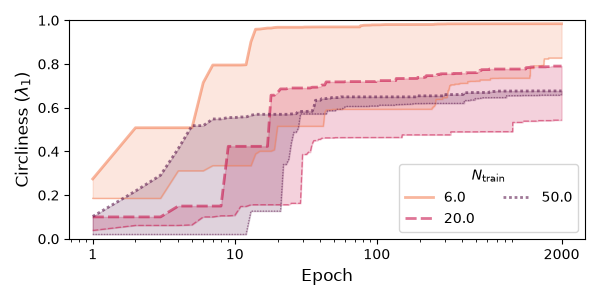

In [26]:
plt.close()
plt.figure(figsize=(6, 3))
sns.lineplot(epoch_vs_train_n, x='epoch', y='fitness', hue='n', style='n', legend=False, linewidth=1.0, alpha=0.5,
             estimator='min', errorbar=None, palette=sns.color_palette("rocket_r", n_colors=len(ns)))
sns.lineplot(epoch_vs_train_n, x='epoch', y='fitness', hue='n', style='n', linewidth=2.0, alpha=0.6,
             estimator='max', errorbar=('pi', 100), palette=sns.color_palette("rocket_r", n_colors=len(ns)))
plt.legend(loc='lower right', ncol=2, title='$N_{\\mathrm{train}}$')
plt.ylim(0, 1)
plt.xscale('log')
plt.xticks((1, 10, 100, 2000))
plt.xlabel('Epoch')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.ScalarFormatter())
plt.ylabel('Circliness ($\\lambda_1$)')
plt.gcf().tight_layout()
plt.show()
plt.savefig('circliness_epoch_vs_train_n.pdf', backend='pgf')

In [8]:
# folder = pl.Path('~/neuromorphic/results/sp25').expanduser()


# def extract_tenn2_maxs(project):
#     with Run(project) as p:
#         _t, _e, fitnesses, *_ = p.read_popfit()
#         arr = np.array([li for li in fitnesses if li])
#         # epoch_idxs = np.indices(arr.shape)[0]
#         max_fitness = np.max(arr)
#         n_robots = p.env['spawners'][0]['n']
#         # print(f"{p.name}\t{behavior.name}\tN: {n_robots}\tmax: {max_fitness}")
#         behavior = p.env['metrics'][0]['name']
#         behavior = behavior.replace('Delaunay Dispersal', 'Delaunay Diffusion')
#         return {
#             'behavior': behavior,
#             'n_robots': n_robots,
#             'max_fitness': max_fitness,
#         }


# files = [pzip for behavior in folder.iterdir()
#          for pzip in list(behavior.iterdir()) if behavior.name != 'diffusion']

# test = extract_tenn2_maxs(next(iter(files)))
# test

In [9]:
# finalfits = process_map(extract_tenn2_maxs, files)

# df1 = pd.DataFrame(finalfits)
# df1

In [10]:
palette = sns.color_palette('deep', 3)
palette.reverse()
palette.extend(sns.color_palette('deep')[3:])
bpalette = {
    'dispersion': palette[0],
    'Dispersion': palette[0],
    'InteragentDispersion': palette[0],
    'aggregation': palette[1],
    'Aggregation': palette[1],
    'milling': palette[2],
    'Circliness': palette[2],
    'diffusion': palette[3],
    'Delaunay Diffusion': palette[3],
}
palette

[(0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [11]:
mill_vs_n_path = pl.Path('results/mill_vs_n-20260907-1000t-test.csv')
mvndf = pd.read_csv(mill_vs_n_path)
mvndf.groupby(['test_n', 'train_n']).agg({'fitness': ['mean', 'std']})


fitness          
                    mean       std
test_n train_n                    
3      4        0.348731  0.133856
       5        0.396753  0.102908
       6        0.317522  0.123642
       7        0.313056  0.144823
       8        0.326442  0.125782
...                  ...       ...
50     30       0.411472  0.093970
       35       0.342425  0.108841
       40       0.411586  0.129885
       45       0.453119  0.095205
       50       0.432006  0.099329

[720 rows x 2 columns]

In [12]:
mvndf[mvndf['train_n'].isin((4, 6, 8, 10, 50))]

,Unnamed: 0,train_n,test_n,seed,metric,fitness
0,0,10,3,3658676650,Circliness,0.703731
1,1,10,3,768519172,Circliness,0.511359
2,2,10,3,113462463,Circliness,0.393691
3,3,10,3,2748406119,Circliness,0.412188
4,4,10,3,1569714666,Circliness,0.336472
...,...,...,...,...,...,...
201595,201595,8,50,811346658,Circliness,0.556446
201596,201596,8,50,665843946,Circliness,0.582051
201597,201597,8,50,3140654713,Circliness,0.487729
201598,201598,8,50,4177464776,Circliness,0.147212


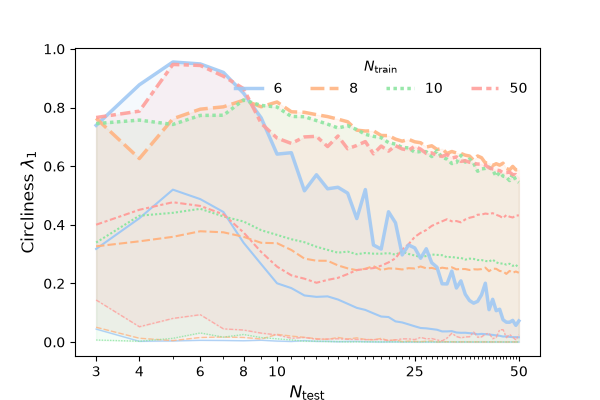

In [13]:
plt.close()
plt.figure(figsize=(6, 4))
# ticks = [3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30, 40, 50]
ticks = [3, 4, 6, 8, 10, 25, 50]
sns.lineplot(mvndf[mvndf['train_n'].isin([6, 8, 10, 50])],
             x='test_n', y='fitness', hue='train_n', style='train_n',
             palette='pastel', errorbar=('pi', 100), linestyle='--',
             legend=False)
ax = plt.gca()
for line in ax.lines:
    line.set_alpha(1)
sns.lineplot(mvndf[mvndf['train_n'].isin([6, 8, 10, 50])],
             x='test_n', y='fitness', hue='train_n', style='train_n',
             palette='pastel', errorbar=None, estimator='max',
             alpha=0.9, linewidth=2.5)
sns.lineplot(mvndf[mvndf['train_n'].isin([6, 8, 10, 50])],
             x='test_n', y='fitness', hue='train_n', style='train_n',
             palette='pastel', errorbar=None, estimator='min', legend=False,
             alpha=0.8, linewidth=1.0)
plt.legend(title="$N_{\\mathrm{train}}$", loc='upper right', ncol=4,
           frameon=False, shadow=False)
plt.xscale('log')
plt.xticks(ticks, [str(x) for x in ticks])
# plt.minorticks_off()
plt.ylabel("Circliness $\\lambda_1$")
plt.xlabel("$N_{\\mathrm{test}}$")
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
# ax.xaxis.minor.locator._subs = 'all'
ax.xaxis.set_minor_locator(matplotlib.ticker.IndexLocator(1, 0))
for fill in ax.collections:
    fill.set_alpha(0.1)
for fill in ax.collections:
    # fill = ax.collections[0]
    color = fill.get_edgecolor()
    color[0][-1] = 0.
    fill._edgecolors = color
plt.show()
plt.gcf().tight_layout()
# ax.lines[0].set_alpha(0.5)
plt.savefig("circliness-vs-n-train.pdf", backend='pgf')


In [48]:
mill_tsr_path = pl.Path('results/mill_tsr-20260910-1000t-e500.csv')
mtsrdf = pd.read_csv(mill_tsr_path)
# mvndf.groupby(['test_n', 'train_n']).agg({'fitness': ['mean', 'std']})
mtsrdf

,Unnamed: 0,train_n,eons_seed,seed,metric,rngstrat,fitness
0,0,6,2026,3658676650,Circliness,TS1,0.133480
1,1,6,2026,768519172,Circliness,TS1,0.543059
2,2,6,2026,113462463,Circliness,TS1,0.441935
3,3,6,2026,2748406119,Circliness,TS1,0.614693
4,4,6,2026,1569714666,Circliness,TS1,0.629605
...,...,...,...,...,...,...,...
2695,2695,10,2028,811346658,Circliness,TSR,0.426334
2696,2696,10,2028,665843946,Circliness,TSR,0.645280
2697,2697,10,2028,3140654713,Circliness,TSR,0.540440
2698,2698,10,2028,4177464776,Circliness,TSR,0.267795


0       False
1       False
2       False
3       False
4       False
        ...  
2695     True
2696     True
2697     True
2698     True
2699     True
Name: mtsrdf, Length: 2700, dtype: bool

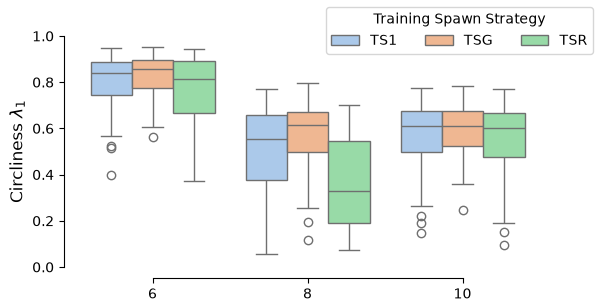

In [ ]:
plt.close()
plt.figure(figsize=(6, 3))
selections = [
    (6, 'TS1', 2028),
    (6, 'TSG', 2027),
    (6, 'TSR', 2027),
    (8, 'TS1', 2028),
    (8, 'TSG', 2028),
    (8, 'TSR', 2028),
    (10, 'TS1', 2026),
    (10, 'TSG', 2028),
    (10, 'TSR', 2028),
]
# sns.boxplot(mtsrdf[mtsrdf['train_n'] == 10], x='rngstrat', y='fitness', hue='eons_seed', palette='pastel')  # for choosing seed
mask = pd.Series(mtsrdf[['train_n', 'rngstrat', 'eons_seed']].itertuples(index=False), name='mtsrdf').isin(selections)
selected = mtsrdf[mask]
order = ['TS1', 'TSG', 'TSR']
sns.boxplot(selected, x='train_n', y='fitness', hue='rngstrat', palette='pastel', hue_order=order)
plt.legend().remove()
# plt.gcf().legend(title="seed", loc='outside upper center', ncol=3,)  # for choosing seed
plt.ylim(0, 1)
sns.despine(offset=8, trim=True)
plt.gcf().legend(title="Training Spawn Strategy", loc='outside upper right', ncol=3,)
plt.ylabel("Circliness $\\lambda_1$")
plt.xlabel("$N$ agents")
plt.show()
plt.gcf().tight_layout()
plt.savefig("circliness-rngstrat.pdf", backend='pgf')